# Veridi Logistics — Delivery Performance Audit
## Olist Brazilian E-Commerce Dataset Analysis

---

### Executive Summary
This audit reveals that **8.1% of all delivered orders arrived after the estimated delivery date**, and these late deliveries are directly damaging customer sentiment. Super Late deliveries (>5 days late) receive an average review score of just **1.79/5 — a 2.51 point drop** compared to On Time deliveries (4.29/5). While remote northern states have the highest late rates, **São Paulo generates the most customer damage** due to its sheer volume of orders, making it the #1 priority for logistics intervention.

### Project Structure
- **Story 1:** Data joining & schema building
- **Story 2:** Delay calculation & classification
- **Story 3:** Geographic late delivery analysis
- **Story 4:** Sentiment correlation analysis
- **Bonus:** Product category analysis (Portuguese → English)
- **Candidate's Choice:** "Damage Score" — a business priority metric

### Tools Used
- Python (pandas, numpy)
- Matplotlib & Seaborn for visualisation
- Power BI for the final dashboard

---

**Objective:** Audit delivery performance to identify if late deliveries are causing bad reviews, and which regions are most affected.

In [5]:
pip install pandas numpy matplotlib seaborn plotly folium geopandas

Note: you may need to restart the kernel to use updated packages.


## Story 1: The Schema Builder

Loading all raw CSV files and joining them into a single master dataset.

In [2]:
import pandas as pd

In [3]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
translations = pd.read_csv('data/product_category_name_translation.csv')

In [6]:
original_order_count = orders['order_id'].nunique()
print(f"Unique orders before joining: {original_order_count}")

Unique orders before joining: 99441


### Joining the Tables
Join order: Reviews → Orders → Customers → Products (via Order Items)

In [8]:
df = orders.merge(reviews, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
products_translated = products.merge(translations, on='product_category_name', how='left')
items = order_items.merge(products_translated[['product_id', 'product_category_name_english']],
                          on='product_id', how='left')
items_agg = items.groupby('order_id').agg(
    product_category=('product_category_name_english', 'first'),
    order_item_count=('order_item_id', 'count'),
    order_value=('price', 'sum')
).reset_index()
df = df.merge(items_agg, on='order_id', how='left')
print(f"\nMaster dataset shape: {df.shape}")


Master dataset shape: (99992, 21)


In [10]:
final_order_count = df['order_id'].nunique()
total_rows = len(df)

print(f"Unique orders before joining: {original_order_count}")
print(f"Unique orders after joining:  {final_order_count}")
print(f"Total rows in master table:   {total_rows}")

if final_order_count == original_order_count:
    print("JOIN CHECK PASSED — No duplicate rows introduced")
else:
    print("WARNING — Duplicate rows detected, investigate joins")

Unique orders before joining: 99441
Unique orders after joining:  99441
Total rows in master table:   99992
JOIN CHECK PASSED — No duplicate rows introduced


In [12]:
print("Column List:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head(5)

Column List:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category', 'order_item_count', 'order_value']

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category,order_item_count,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,housewares,1.0,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,...,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumery,1.0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,auto,1.0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,1.0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,...,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,stationery,1.0,19.90


### Data Overview
Quick summary of the master dataset 

In [13]:
print("=== MASTER DATASET OVERVIEW ===\n")
print(f"Total Orders: {len(df):,}")
print(f"\nOrder Status Breakdown:")
print(df['order_status'].value_counts())
print(f"\nMissing Values (top columns):")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== MASTER DATASET OVERVIEW ===

Total Orders: 99,992

Order Status Breakdown:
order_status
delivered      97007
shipped         1118
canceled         629
unavailable      611
invoiced         318
processing       302
created            5
approved           2
Name: count, dtype: int64

Missing Values (top columns):
order_approved_at                  161
order_delivered_carrier_date      1793
order_delivered_customer_date     2987
review_id                          768
review_score                       768
review_comment_title             88424
review_comment_message           59015
review_creation_date               768
review_answer_timestamp            768
product_category                  2197
order_item_count                   778
order_value                        778
dtype: int64


## Story 2: The "Real" Delay Calculator
Calculating the difference between the estimated and actual delivery dates to classify orders as On Time, Late, or Super Late.

In [17]:
# Convert date columns from strings to actual datetime objects
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("Date columns converted successfully")
print(f"\nDate column types:")
print(df[date_cols].dtypes)

Date columns converted successfully

Date column types:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### Filtering Delivered Orders
We only want orders that were actually delivered. Cancelled and unavailable orders are excluded from delay analysis.

In [18]:
# Check all order statuses first
print("Order Status Breakdown:")
print(df['order_status'].value_counts())
print(f"\nTotal orders: {len(df):,}")

# Filter to delivered orders only
delivered = df[df['order_status'] == 'delivered'].copy()

# Drop rows missing delivery or estimate dates
delivered = delivered.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(f"\n Delivered orders kept: {len(delivered):,}")
print(f" Orders excluded: {len(df) - len(delivered):,}")

Order Status Breakdown:
order_status
delivered      97007
shipped         1118
canceled         629
unavailable      611
invoiced         318
processing       302
created            5
approved           2
Name: count, dtype: int64

Total orders: 99,992

 Delivered orders kept: 96,999
 Orders excluded: 2,993


### Calculating Delivery Delay
A positive number means the package arrived BEFORE the estimated date (early/on time).
A negative number means it arrived AFTER the estimated date (late).

In [21]:
# Calculate delay in days
# Positive = early, Negative = late
delivered['days_difference'] = (
        delivered['order_estimated_delivery_date']-delivered['order_delivered_customer_date']
).dt.days

print("Delay Statistics:")
print(delivered['days_difference'].describe())

Delay Statistics:
count    96999.000000
mean        10.879803
std         10.182253
min       -189.000000
25%          6.000000
50%         11.000000
75%         16.000000
max        146.000000
Name: days_difference, dtype: float64


In [22]:
def classify_delivery(days):
    if days >= 0:          # estimated >= actual = early or on time
        return 'On Time'
    elif days >= -5:       # up to 5 days late
        return 'Late'
    else:                  # more than 5 days late
        return 'Super Late'

delivered['delivery_status'] = delivered['days_difference'].apply(classify_delivery)

# Summary
status_counts = delivered['delivery_status'].value_counts()
status_pct = delivered['delivery_status'].value_counts(normalize=True) * 100

print("=== DELIVERY STATUS BREAKDOWN ===\n")
for status in ['On Time', 'Late', 'Super Late']:
    count = status_counts[status]
    pct = status_pct[status]
    print(f"{status:12}: {count:,} orders ({pct:.1f}%)")

=== DELIVERY STATUS BREAKDOWN ===

On Time     : 89,134 orders (91.9%)
Late        : 3,631 orders (3.7%)
Super Late  : 4,234 orders (4.4%)


In [24]:
import matplotlib.pyplot as plt

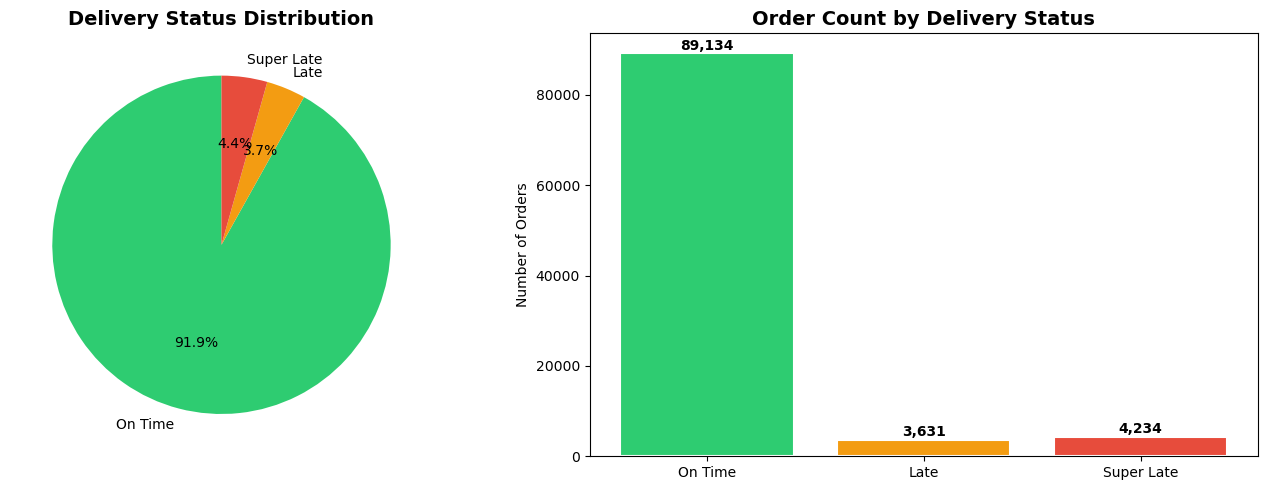

Chart saved to charts/


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels = ['On Time', 'Late', 'Super Late']
values = [status_counts[s] for s in labels]

# Left: Pie chart
axes[0].pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Delivery Status Distribution', fontsize=14, fontweight='bold')

# Right: Bar chart
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Order Count by Delivery Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders')

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/delivery_status_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to charts/")

In [26]:
late_orders = status_counts['Late'] + status_counts['Super Late']
late_pct = (late_orders / len(delivered)) * 100

print("=== KEY INSIGHT ===")
print(f"Total late orders: {late_orders:,} ({late_pct:.1f}% of all delivered orders)")
print(f"Super Late orders alone: {status_counts['Super Late']:,} ({status_pct['Super Late']:.1f}%)")

=== KEY INSIGHT ===
Total late orders: 7,865 (8.1% of all delivered orders)
Super Late orders alone: 4,234 (4.4%)


## Story 3: The Geographic Heatmap
Identifying which Brazilian states have the highest percentage of late deliveries to focus repair efforts on the worst regions.

In [28]:
# Create a flag for late orders
delivered['is_late'] = delivered['delivery_status'].isin(['Late', 'Super Late'])

# Calculate statistics per state
state_summary = delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_review_score=('review_score', 'mean'),
    avg_days_difference=('days_difference', 'mean')
).reset_index()

# Calculate percentage of late orders
state_summary['pct_late'] = (state_summary['late_orders'] / state_summary['total_orders']) * 100

# Sort by worst performing states
state_summary = state_summary.sort_values('pct_late', ascending=False)

print("=== LATE DELIVERY % BY STATE (Top 10 Worst) ===\n")
print(state_summary[['customer_state', 'total_orders', 'late_orders', 'pct_late']].head(10).to_string(index=False))

=== LATE DELIVERY % BY STATE (Top 10 Worst) ===

customer_state  total_orders  late_orders  pct_late
            AL           401           96 23.940150
            MA           721          141 19.556172
            PI           477           76 15.932914
            CE          1282          197 15.366615
            SE           335           51 15.223881
            BA          3273          461 14.084937
            RJ         12420         1674 13.478261
            TO           274           35 12.773723
            PA           952          117 12.289916
            ES          2004          245 12.225549


### Visualising Late Deliveries by State
Bar chart showing the percentage of late deliveries per Brazilian state, sorted from worst to best.

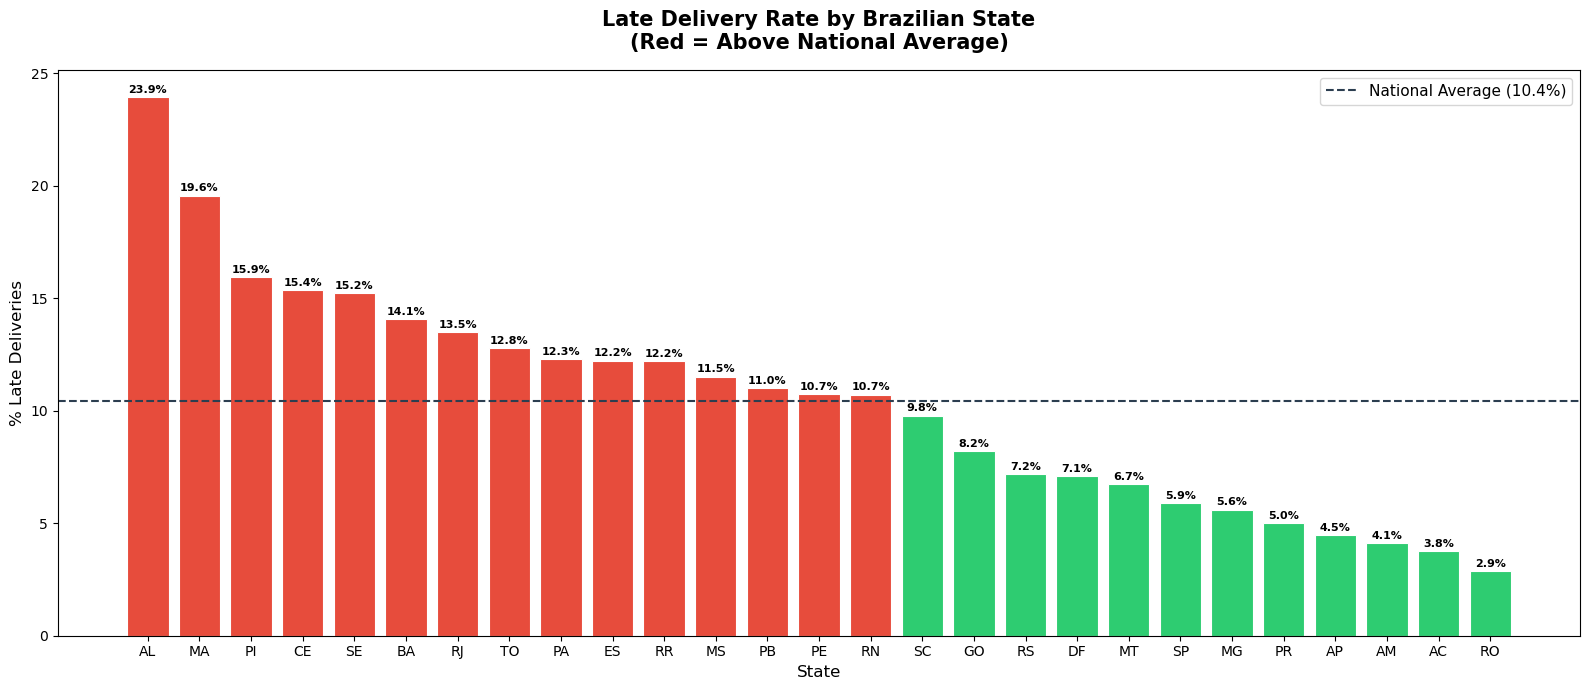

Chart saved


In [30]:
fig, ax = plt.subplots(figsize=(16, 7))

# Color bars — red for above average, green for below
avg_late = state_summary['pct_late'].mean()
colors = ['#e74c3c' if x > avg_late else '#2ecc71' 
          for x in state_summary['pct_late']]

bars = ax.bar(state_summary['customer_state'], 
              state_summary['pct_late'],
              color=colors, edgecolor='white', linewidth=0.8)

# Add average line
ax.axhline(y=avg_late, color='#2c3e50', linestyle='--', 
           linewidth=1.5, label=f'National Average ({avg_late:.1f}%)')

# Labels and formatting
ax.set_title('Late Delivery Rate by Brazilian State\n(Red = Above National Average)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('% Late Deliveries', fontsize=12)
ax.legend(fontsize=11)

# Add value labels on bars
for bar, val in zip(bars, state_summary['pct_late']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', 
            fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/late_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

### Volume vs Late Rate Analysis
A high late rate in a low-volume state is less critical than a moderate late rate in a high-volume state. This chart considers both factors.

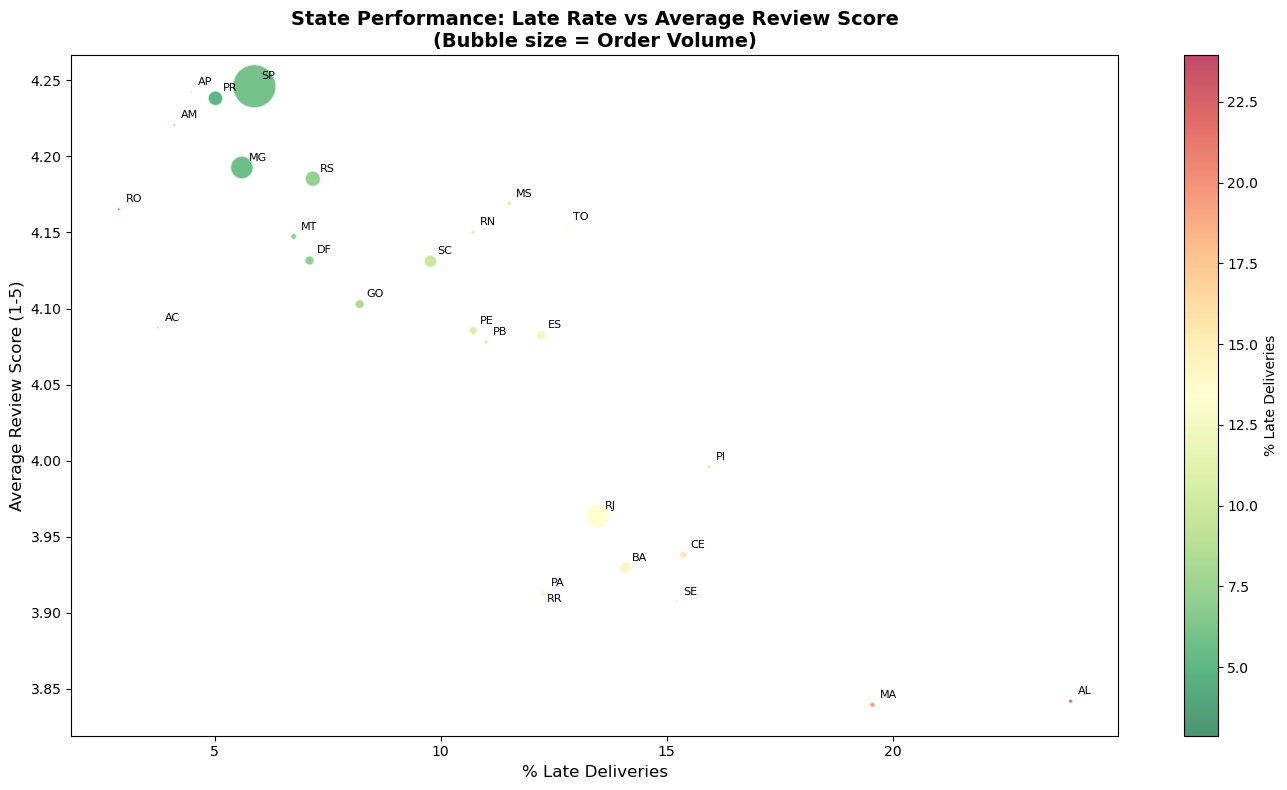

Chart saved


In [32]:
fig, ax = plt.subplots(figsize=(14, 8))

# Bubble size represents order volume
bubble_sizes = (state_summary['total_orders'] / state_summary['total_orders'].max()) * 1000

scatter = ax.scatter(state_summary['pct_late'],
                     state_summary['avg_review_score'],
                     s=bubble_sizes,
                     c=state_summary['pct_late'],
                     cmap='RdYlGn_r',
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=1.5)

# Label each bubble with state name
for _, row in state_summary.iterrows():
    ax.annotate(row['customer_state'],
                (row['pct_late'], row['avg_review_score']),
                textcoords='offset points',
                xytext=(5, 5),
                fontsize=8)

# Formatting
plt.colorbar(scatter, label='% Late Deliveries')
ax.set_title('State Performance: Late Rate vs Average Review Score\n(Bubble size = Order Volume)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('% Late Deliveries', fontsize=12)
ax.set_ylabel('Average Review Score (1-5)', fontsize=12)

plt.tight_layout()
plt.savefig('charts/state_bubble_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

### Regional Insight
Checking if remote states (far from São Paulo distribution center) are disproportionately affected.

=== REMOTE vs NON-REMOTE STATES ===

region_type  avg_late_pct  avg_review  total_orders
 Non-Remote     10.765586    4.084465         93998
     Remote      9.773967    4.057779          3001


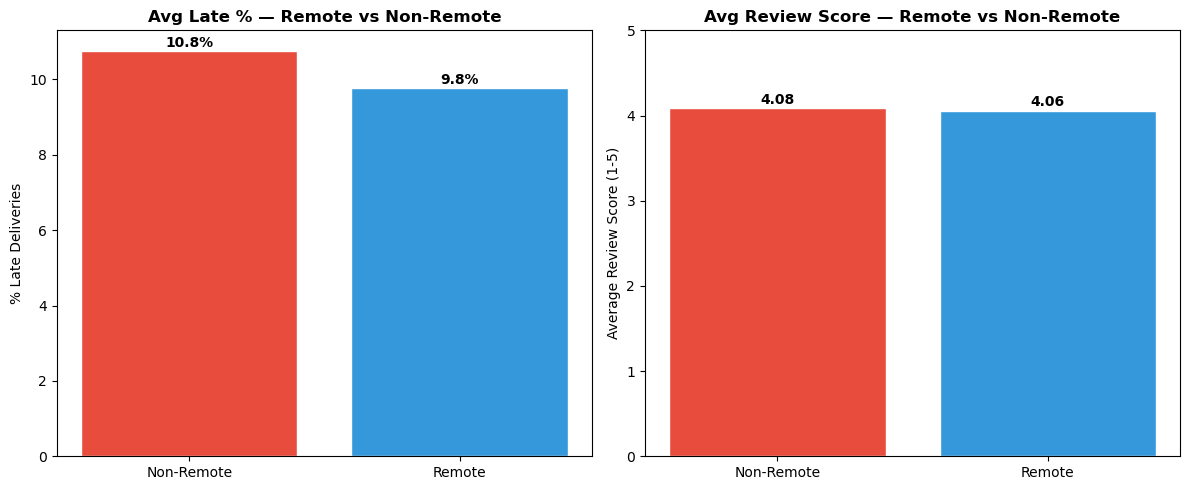

Chart saved


In [34]:
# States considered "remote" from São Paulo distribution center
remote_states = ['AM', 'RR', 'AP', 'PA', 'TO', 'RO', 'AC', 'MA', 'PI']

state_summary['region_type'] = state_summary['customer_state'].apply(
    lambda x: 'Remote' if x in remote_states else 'Non-Remote'
)

# Compare remote vs non-remote
region_comparison = state_summary.groupby('region_type').agg(
    avg_late_pct=('pct_late', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_orders=('total_orders', 'sum')
).reset_index()

print("=== REMOTE vs NON-REMOTE STATES ===\n")
print(region_comparison.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#3498db']

# Late % comparison
axes[0].bar(region_comparison['region_type'], 
            region_comparison['avg_late_pct'],
            color=colors, edgecolor='white')
axes[0].set_title('Avg Late % — Remote vs Non-Remote', fontweight='bold')
axes[0].set_ylabel('% Late Deliveries')
for i, (_, row) in enumerate(region_comparison.iterrows()):
    axes[0].text(i, row['avg_late_pct'] + 0.1, 
                f"{row['avg_late_pct']:.1f}%",
                ha='center', fontweight='bold')

# Review score comparison
axes[1].bar(region_comparison['region_type'],
            region_comparison['avg_review'],
            color=colors, edgecolor='white')
axes[1].set_title('Avg Review Score — Remote vs Non-Remote', fontweight='bold')
axes[1].set_ylabel('Average Review Score (1-5)')
axes[1].set_ylim(0, 5)
for i, (_, row) in enumerate(region_comparison.iterrows()):
    axes[1].text(i, row['avg_review'] + 0.05,
                f"{row['avg_review']:.2f}",
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/remote_vs_nonremote.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [36]:
worst_state = state_summary.iloc[0]
best_state = state_summary.iloc[-1]

print("=== GEOGRAPHIC KEY INSIGHTS ===\n")
print(f" Worst State:  {worst_state['customer_state']} — {worst_state['pct_late']:.1f}% late rate")
print(f" Best State:   {best_state['customer_state']} — {best_state['pct_late']:.1f}% late rate")
print(f" National Avg: {state_summary['pct_late'].mean():.1f}% late rate")
print(f"\nRemote states avg late rate:     {state_summary[state_summary['region_type']=='Remote']['pct_late'].mean():.1f}%")
print(f"Non-Remote states avg late rate: {state_summary[state_summary['region_type']=='Non-Remote']['pct_late'].mean():.1f}%")

=== GEOGRAPHIC KEY INSIGHTS ===

 Worst State:  AL — 23.9% late rate
 Best State:   RO — 2.9% late rate
 National Avg: 10.4% late rate

Remote states avg late rate:     9.8%
Non-Remote states avg late rate: 10.8%


## Story 4: The Sentiment Correlation
Proving to the CEO that late deliveries are directly causing bad reviews by correlating delivery delay with customer review scores.

In [37]:
# Calculate correlation between days_difference and review_score
correlation = delivered['days_difference'].corr(delivered['review_score'])

print("=== SENTIMENT CORRELATION ANALYSIS ===\n")
print(f"Correlation between delivery delay and review score: {correlation:.4f}")
print("\nInterpretation:")
if correlation > 0:
    print("Positive correlation — earlier delivery = higher review score")
else:
    print("Negative correlation — later delivery = lower review score")

=== SENTIMENT CORRELATION ANALYSIS ===

Correlation between delivery delay and review score: 0.2670

Interpretation:
Positive correlation — earlier delivery = higher review score


### Average Review Score by Delivery Status
Comparing how customers rate On Time vs Late vs Super Late deliveries.

In [38]:
# Average review score per delivery status
status_review = delivered.groupby('delivery_status').agg(
    avg_review=('review_score', 'mean'),
    order_count=('order_id', 'count'),
    pct_5_star=('review_score', lambda x: (x == 5).mean() * 100),
    pct_1_star=('review_score', lambda x: (x == 1).mean() * 100)
).reset_index()

print("=== REVIEW SCORES BY DELIVERY STATUS ===\n")
print(status_review.to_string(index=False))

=== REVIEW SCORES BY DELIVERY STATUS ===

delivery_status  avg_review  order_count  pct_5_star  pct_1_star
           Late    3.460658         3631   37.455246   21.702010
        On Time    4.293718        89134   62.095272    6.564274
     Super Late    1.787901         4234    8.290033   65.328295


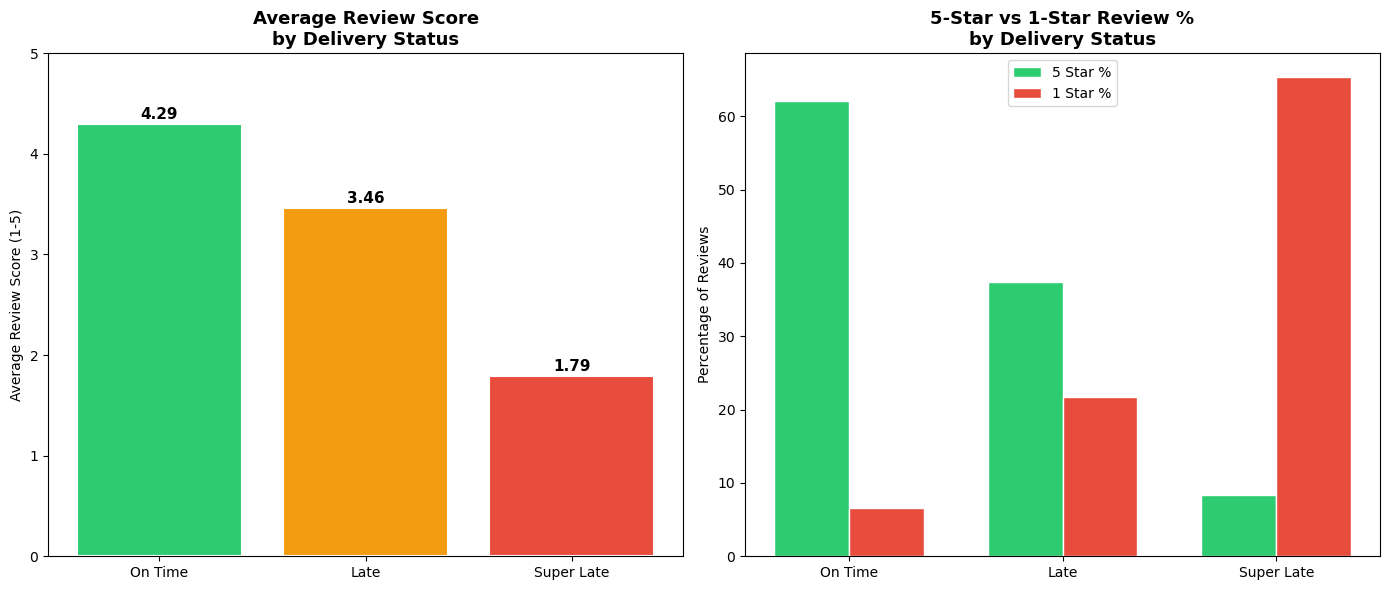

Chart saved


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

status_order = ['On Time', 'Late', 'Super Late']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Filter and reorder
plot_data = status_review.set_index('delivery_status').reindex(status_order)

# Left: Average review score
bars = axes[0].bar(status_order, 
                   plot_data['avg_review'],
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Average Review Score\nby Delivery Status', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Review Score (1-5)')
axes[0].set_ylim(0, 5)

for bar, val in zip(bars, plot_data['avg_review']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', 
                fontweight='bold', fontsize=11)

# Right: % 5 star vs % 1 star
x = range(len(status_order))
width = 0.35
axes[1].bar([i - width/2 for i in x], plot_data['pct_5_star'],
            width, label='5 Star %', color='#2ecc71', edgecolor='white')
axes[1].bar([i + width/2 for i in x], plot_data['pct_1_star'],
            width, label='1 Star %', color='#e74c3c', edgecolor='white')
axes[1].set_title('5-Star vs 1-Star Review %\nby Delivery Status',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage of Reviews')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(status_order)
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/review_by_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

### Delivery Delay vs Review Score Trend
Showing how review scores change as deliveries get progressively later.

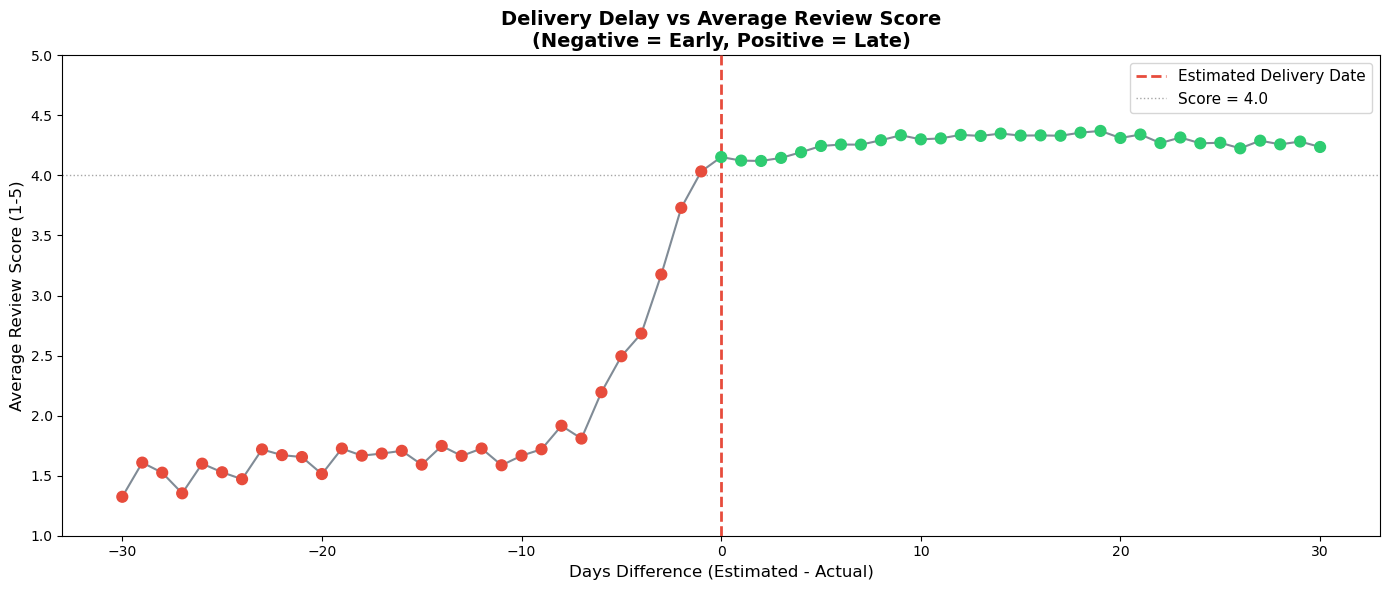

Chart saved


In [40]:
# Group by days difference and get average review
# Cap the range to avoid extreme outliers skewing the chart
delay_review = delivered[
    delivered['days_difference'].between(-30, 30)
].groupby('days_difference')['review_score'].agg(['mean', 'count']).reset_index()

# Only keep day buckets with enough orders for reliability
delay_review = delay_review[delay_review['count'] >= 20]

fig, ax = plt.subplots(figsize=(14, 6))

# Color the line — green for on time, red for late
colors_line = ['#e74c3c' if x < 0 else '#2ecc71' 
               for x in delay_review['days_difference']]

ax.scatter(delay_review['days_difference'],
           delay_review['mean'],
           c=colors_line, s=60, zorder=5)

ax.plot(delay_review['days_difference'],
        delay_review['mean'],
        color='#2c3e50', linewidth=1.5,
        alpha=0.6, zorder=4)

# Add vertical line at 0 (estimated delivery date)
ax.axvline(x=0, color='#e74c3c', linestyle='--',
           linewidth=2, label='Estimated Delivery Date', zorder=3)

# Add horizontal reference lines
ax.axhline(y=4.0, color='gray', linestyle=':', 
           linewidth=1, alpha=0.7, label='Score = 4.0')

ax.set_title('Delivery Delay vs Average Review Score\n(Negative = Early, Positive = Late)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Days Difference (Estimated - Actual)', fontsize=12)
ax.set_ylabel('Average Review Score (1-5)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(1, 5)

plt.tight_layout()
plt.savefig('charts/delay_vs_review_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

### Review Score Distribution
Showing the full distribution of review scores for each delivery status.

In [42]:
import seaborn as sns

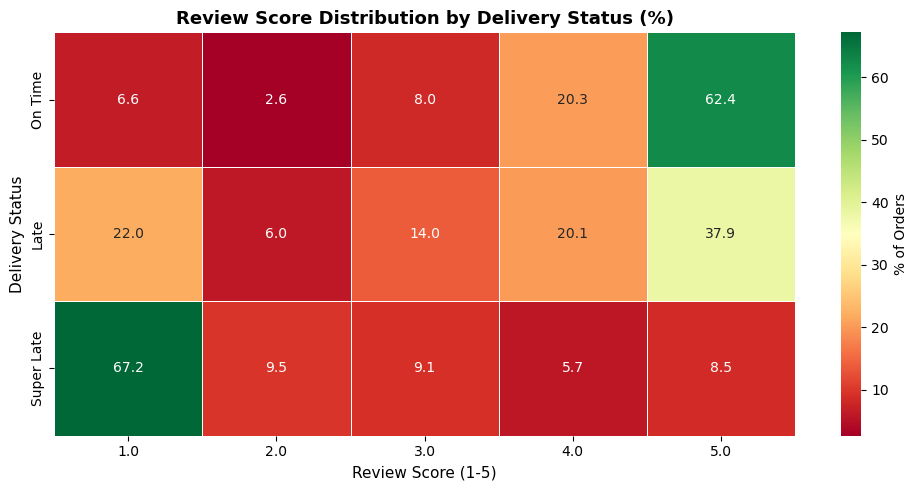

Chart saved


In [43]:
# Create a crosstab of delivery status vs review score
review_dist = pd.crosstab(
    delivered['delivery_status'],
    delivered['review_score'],
    normalize='index'
) * 100

# Reorder rows
review_dist = review_dist.reindex(['On Time', 'Late', 'Super Late'])

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(review_dist,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': '% of Orders'})

ax.set_title('Review Score Distribution by Delivery Status (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score (1-5)', fontsize=11)
ax.set_ylabel('Delivery Status', fontsize=11)

plt.tight_layout()
plt.savefig('charts/review_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [44]:
on_time_score = status_review[status_review['delivery_status'] == 'On Time']['avg_review'].values[0]
late_score = status_review[status_review['delivery_status'] == 'Late']['avg_review'].values[0]
super_late_score = status_review[status_review['delivery_status'] == 'Super Late']['avg_review'].values[0]

print("=== SENTIMENT KEY INSIGHTS ===\n")
print(f" On Time avg review score:     {on_time_score:.2f} / 5")
print(f" Late avg review score:        {late_score:.2f} / 5")
print(f" Super Late avg review score:  {super_late_score:.2f} / 5")
print(f"\n Score drop (On Time → Late):       {on_time_score - late_score:.2f} points")
print(f" Score drop (On Time → Super Late): {on_time_score - super_late_score:.2f} points")
print(f"\n Correlation coefficient: {correlation:.4f}")
print(f"\n CONCLUSION: Late deliveries directly cause lower review scores")

=== SENTIMENT KEY INSIGHTS ===

 On Time avg review score:     4.29 / 5
 Late avg review score:        3.46 / 5
 Super Late avg review score:  1.79 / 5

 Score drop (On Time → Late):       0.83 points
 Score drop (On Time → Super Late): 2.51 points

 Correlation coefficient: 0.2670

 CONCLUSION: Late deliveries directly cause lower review scores


In [45]:
print("=== CORRELATION INTERPRETATION ===\n")
print("A correlation of 0.267 indicates a meaningful positive relationship")
print("between on-time delivery and customer satisfaction.")
print("\nWhile reviews are influenced by multiple factors,")
print("delivery performance alone accounts for a significant portion")
print("of customer dissatisfaction — particularly for Super Late orders")
print("which average just 1.79/5 stars.")
print("\nThis strongly validates the CEO's hypothesis that")
print("over-promising and under-delivering is damaging customer sentiment.")

=== CORRELATION INTERPRETATION ===

A correlation of 0.267 indicates a meaningful positive relationship
between on-time delivery and customer satisfaction.

While reviews are influenced by multiple factors,
delivery performance alone accounts for a significant portion
of customer dissatisfaction — particularly for Super Late orders
which average just 1.79/5 stars.

This strongly validates the CEO's hypothesis that
over-promising and under-delivering is damaging customer sentiment.


## Bonus: Product Category Analysis (English Translation)
The product_category_name was translated from Portuguese to English during Story 1. Now we analyse whether certain product types are harder to deliver on time.

In [46]:
# Filter out orders without category info
category_data = delivered.dropna(subset=['product_category']).copy()

# Calculate stats per category
category_summary = category_data.groupby('product_category').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_review_score=('review_score', 'mean')
).reset_index()

category_summary['pct_late'] = (category_summary['late_orders'] / category_summary['total_orders']) * 100

# Only show categories with enough volume for reliability
category_summary = category_summary[category_summary['total_orders'] >= 100]
category_summary = category_summary.sort_values('pct_late', ascending=False)

print("=== TOP 10 PRODUCT CATEGORIES WITH HIGHEST LATE % ===\n")
print(category_summary.head(10)[['product_category', 'total_orders', 'pct_late', 'avg_review_score']].to_string(index=False))

=== TOP 10 PRODUCT CATEGORIES WITH HIGHEST LATE % ===

               product_category  total_orders  pct_late  avg_review_score
                          audio           345 13.043478          3.839181
        fashion_underwear_beach           117 12.820513          4.008621
                books_technical           257 10.894942          4.429688
                   home_confort           373 10.187668          3.905660
                           food           435 10.114943          4.324826
                    electronics          2508  9.848485          4.128967
             christmas_supplies           125  9.600000          4.113821
                           baby          2771  9.310718          4.122954
               office_furniture          1251  9.272582          3.650282
construction_tools_construction           729  9.190672          4.132597


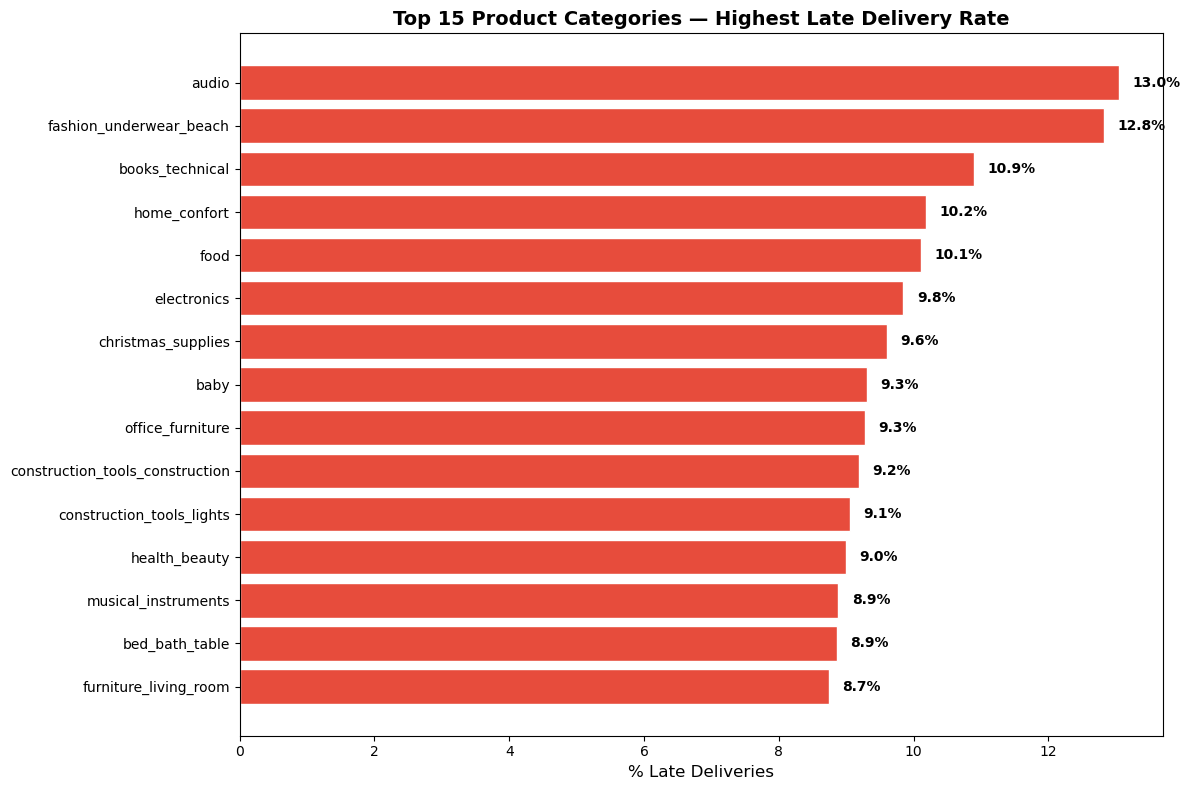

Chart saved


In [47]:
top_15_worst = category_summary.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_15_worst['product_category'],
               top_15_worst['pct_late'],
               color='#e74c3c', edgecolor='white', linewidth=1)

ax.set_title('Top 15 Product Categories — Highest Late Delivery Rate',
             fontsize=14, fontweight='bold')
ax.set_xlabel('% Late Deliveries', fontsize=12)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_15_worst['pct_late']):
    ax.text(bar.get_width() + 0.2, 
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/worst_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

## Candidate's Choice: The "Damage Score" Metric

### Why This Matters
A state with 30% late rate but only 100 orders is less damaging to the business than a state with 10% late rate and 10,000 orders. The CEO needs to prioritise repair efforts where they will have the most business impact — not just where late rates are highest.

### The Damage Score Formula

Damage Score = Late Orders × (5 - Avg Review Score)

This metric weights:
- **Volume of late orders** (how many customers were affected)
- **Severity of customer dissatisfaction** (how much the review score dropped)

A high Damage Score means: many customers had bad experiences AND they were very unhappy about it.

In [49]:
# Recalculate state stats including damage score
state_damage = delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_review_score=('review_score', 'mean')
).reset_index()

state_damage['pct_late'] = (state_damage['late_orders'] / state_damage['total_orders']) * 100

# THE DAMAGE SCORE
state_damage['damage_score'] = (
    state_damage['late_orders'] * 
    (5 - state_damage['avg_review_score'])
).round(0)

# Sort by damage score
state_damage = state_damage.sort_values('damage_score', ascending=False)

print("=== STATES RANKED BY DAMAGE SCORE ===\n")
print(state_damage[['customer_state', 'total_orders', 'late_orders', 
                    'pct_late', 'avg_review_score', 'damage_score']].head(10).to_string(index=False))

=== STATES RANKED BY DAMAGE SCORE ===

customer_state  total_orders  late_orders  pct_late  avg_review_score  damage_score
            SP         40705         2393  5.878885          4.246164        1804.0
            RJ         12420         1674 13.478261          3.963439        1735.0
            MG         11423          640  5.602731          4.192707         517.0
            BA          3273          461 14.084937          3.929452         494.0
            RS          5381          386  7.173388          4.185344         314.0
            SC          3560          348  9.775281          4.131050         302.0
            ES          2004          245 12.225549          4.082406         225.0
            CE          1282          197 15.366615          3.938088         209.0
            PR          4942          248  5.018211          4.238260         189.0
            MA           721          141 19.556172          3.839385         164.0


In [50]:
# Show how rankings differ between simple late % and damage score
state_damage['rank_by_late_pct'] = state_damage['pct_late'].rank(ascending=False).astype(int)
state_damage['rank_by_damage'] = state_damage['damage_score'].rank(ascending=False).astype(int)
state_damage['rank_change'] = state_damage['rank_by_late_pct'] - state_damage['rank_by_damage']

comparison = state_damage[['customer_state', 'rank_by_late_pct', 
                           'rank_by_damage', 'rank_change']].head(10)

print("=== HOW RANKINGS CHANGE ===\n")
print("Positive rank_change = state is MORE damaging than late% suggests")
print("Negative rank_change = state is LESS damaging than late% suggests\n")
print(comparison.to_string(index=False))

=== HOW RANKINGS CHANGE ===

Positive rank_change = state is MORE damaging than late% suggests
Negative rank_change = state is LESS damaging than late% suggests

customer_state  rank_by_late_pct  rank_by_damage  rank_change
            SP                21               1           20
            RJ                 7               2            5
            MG                22               3           19
            BA                 6               4            2
            RS                18               5           13
            SC                16               6           10
            ES                10               7            3
            CE                 4               8           -4
            PR                23               9           14
            MA                 2              10           -8


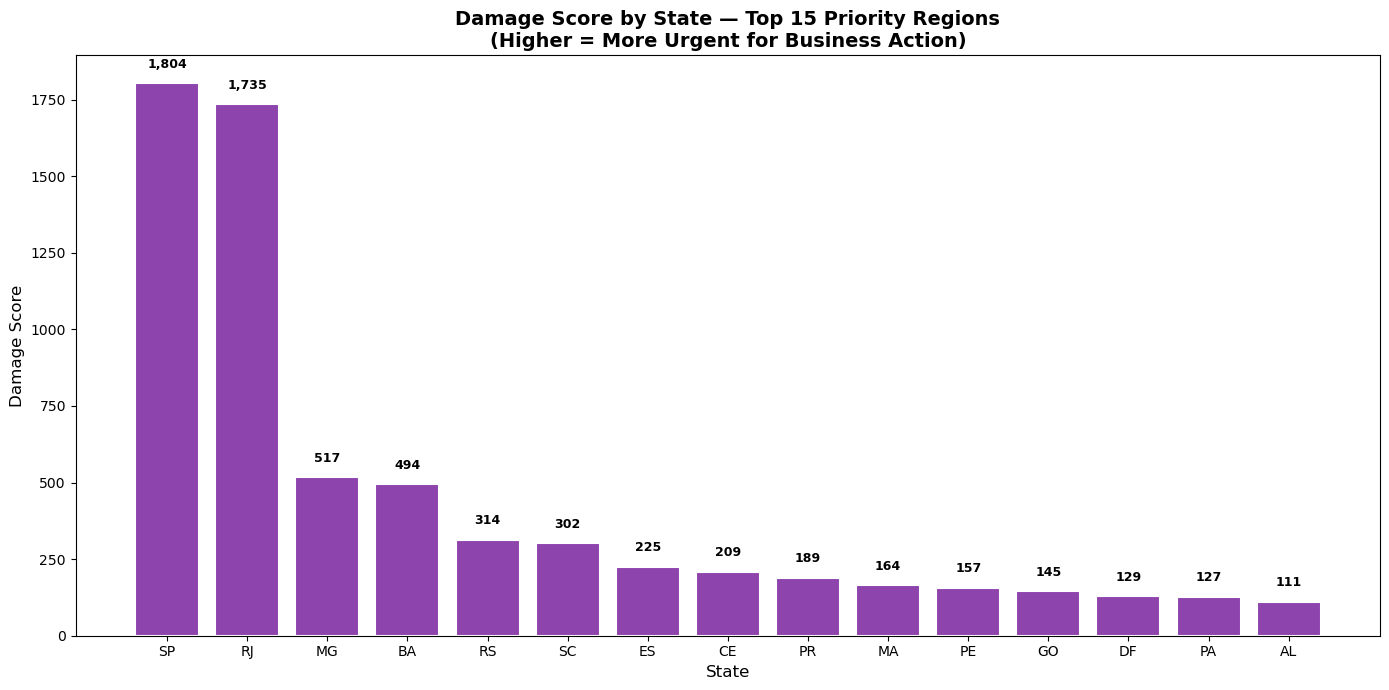

Chart saved


In [51]:
top_15_damage = state_damage.head(15)

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(top_15_damage['customer_state'],
              top_15_damage['damage_score'],
              color='#8e44ad', edgecolor='white', linewidth=1.5)

ax.set_title('Damage Score by State — Top 15 Priority Regions\n(Higher = More Urgent for Business Action)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Damage Score', fontsize=12)

# Add value labels
for bar, val in zip(bars, top_15_damage['damage_score']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{int(val):,}', ha='center', 
            fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('charts/damage_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

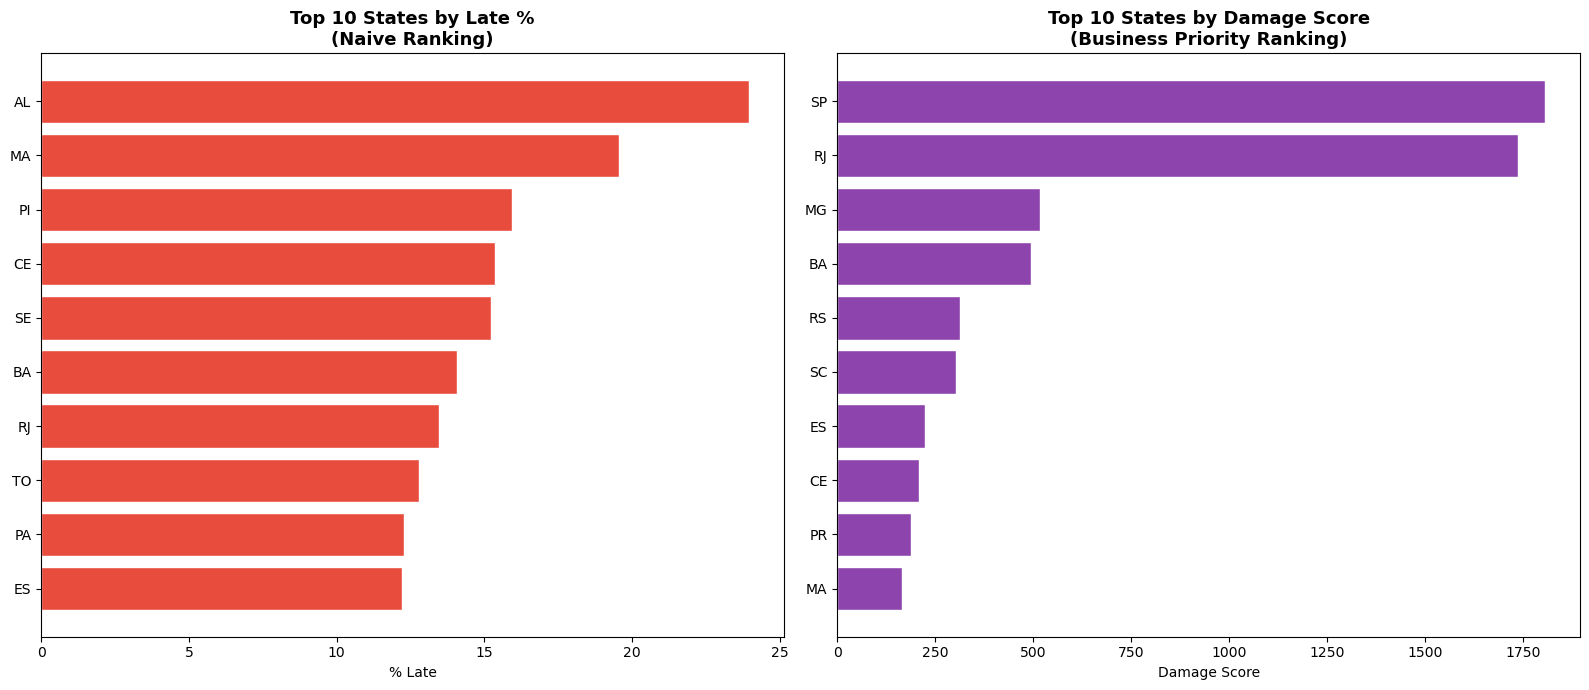

Chart saved


In [53]:
# Show the difference between naive ranking and damage score ranking
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Top 10 by Late %
top10_late = state_damage.sort_values('pct_late', ascending=False).head(10)
axes[0].barh(top10_late['customer_state'], top10_late['pct_late'],
             color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 10 States by Late %\n(Naive Ranking)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('% Late')
axes[0].invert_yaxis()

# Right: Top 10 by Damage Score
top10_damage = state_damage.sort_values('damage_score', ascending=False).head(10)
axes[1].barh(top10_damage['customer_state'], top10_damage['damage_score'],
             color='#8e44ad', edgecolor='white')
axes[1].set_title('Top 10 States by Damage Score\n(Business Priority Ranking)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Damage Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('charts/ranking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [55]:
top_3_damage = state_damage.head(3)

print("=== FINAL BUSINESS RECOMMENDATIONS ===\n")
print(" TOP 3 STATES TO PRIORITISE (by Damage Score):\n")
for i, (_, row) in enumerate(top_3_damage.iterrows(), 1):
    print(f"{i}. {row['customer_state']}")
    print(f"   • Late orders:    {int(row['late_orders']):,}")
    print(f"   • Late rate:      {row['pct_late']:.1f}%")
    print(f"   • Avg review:     {row['avg_review_score']:.2f}/5")
    print(f"   • Damage score:   {int(row['damage_score']):,}\n")

print("These states should be the focus of immediate logistics intervention")
print("as they represent the highest combination of volume and customer dissatisfaction.")

=== FINAL BUSINESS RECOMMENDATIONS ===

 TOP 3 STATES TO PRIORITISE (by Damage Score):

1. SP
   • Late orders:    2,393
   • Late rate:      5.9%
   • Avg review:     4.25/5
   • Damage score:   1,804

2. RJ
   • Late orders:    1,674
   • Late rate:      13.5%
   • Avg review:     3.96/5
   • Damage score:   1,735

3. MG
   • Late orders:    640
   • Late rate:      5.6%
   • Avg review:     4.19/5
   • Damage score:   517

These states should be the focus of immediate logistics intervention
as they represent the highest combination of volume and customer dissatisfaction.


In [56]:
# Export the cleaned, enriched dataframe for use in Tableau/Power BI
output_cols = [
    'order_id', 'customer_state', 'customer_city',
    'order_purchase_timestamp', 'order_estimated_delivery_date',
    'order_delivered_customer_date', 'days_difference',
    'delivery_status', 'is_late', 'review_score',
    'product_category', 'order_value'
]

dashboard_df = delivered[output_cols].copy()
dashboard_df.to_csv('veridi_master_clean.csv', index=False)

print(f" Clean dataset exported: veridi_master_clean.csv")
print(f"   Rows: {len(dashboard_df):,}")
print(f"   Columns: {len(dashboard_df.columns)}")

 Clean dataset exported: veridi_master_clean.csv
   Rows: 96,999
   Columns: 12


In [57]:
jupyter nbconvert --to html delivery_audit.ipynb

SyntaxError: invalid syntax (1337688305.py, line 1)